# TEM schematic figure

Three-panel illustration: geological structure, TEM forward response, and the corresponding depth vs resistivity model.

In [2]:
import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
import numpy as np

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import fwd_circle_central
from pytem.inversion import invert

plt.rcParams['figure.dpi'] = 115


In [3]:
# Three-panel schematic: geological cross-section, TEM forward response, resistivity-depth model.

# Synthetic layered earth: a sand layer split at the water table (dry above,
# saturated below), a conductive clay layer, a resistive basement.
schematic_thicknesses = np.array([3.0, 8.0, 8.0])
schematic_resistivities = np.array([100.0, 60.0, 15.0, 1000.0])
schematic_depths = np.concatenate([[0.0], np.cumsum(schematic_thicknesses)])
schematic_max_depth = schematic_depths[-1] + 40.0
water_table_depth = schematic_depths[1]

schematic_tx_radius = 30.0
schematic_times = np.logspace(-5, -1, 21)
schematic_dbdt = fwd_circle_central(
    schematic_thicknesses, schematic_resistivities, schematic_tx_radius, schematic_times)

# Noisy synthetic data for a smooth (many-thin-layer) inversion.
noise_frac = 0.02
rng = np.random.default_rng(1)
d_clean = -schematic_dbdt
d_obs = d_clean * (1.0 + noise_frac * rng.standard_normal(d_clean.size))
noise_std = noise_frac * np.abs(d_clean)

# Fine layered mesh for the inversion (independent of the 3-layer true model).
n_inv_layers = 25
thick_inv = np.geomspace(1.0, 6.0, n_inv_layers - 1)
thick_inv *= schematic_max_depth / thick_inv.sum()   # span roughly the true model's depth range
depths_inv = np.concatenate([[0.0], np.cumsum(thick_inv)])

# Regularised Gauss-Newton inversion (library routine): an alpha search targets
# RMS = 1 at each iteration, instead of a fixed smoothing strength, so the model
# is only as smooth as the noise level actually demands. A fixed alpha (as used
# previously) either over-smooths (erasing the clay/basement contrast) or
# under-smooths depending on its value; the automatic search recovers both the
# conductive clay minimum and the resistive basement rise.
m0 = np.log(np.full(n_inv_layers, 100.0))
with contextlib.redirect_stdout(io.StringIO()):
    inv_result = invert(
        obs_data=d_obs, thicknesses=thick_inv, log_resistivities=m0,
        tx_size=schematic_tx_radius, times=schematic_times,
        noise_std=noise_frac, alpha_steps=8, maxit=20,
        max_noise_frac=0.0, transform='dlf', geometry='circle_central',
    )

smooth_rho = inv_result['resistivities']

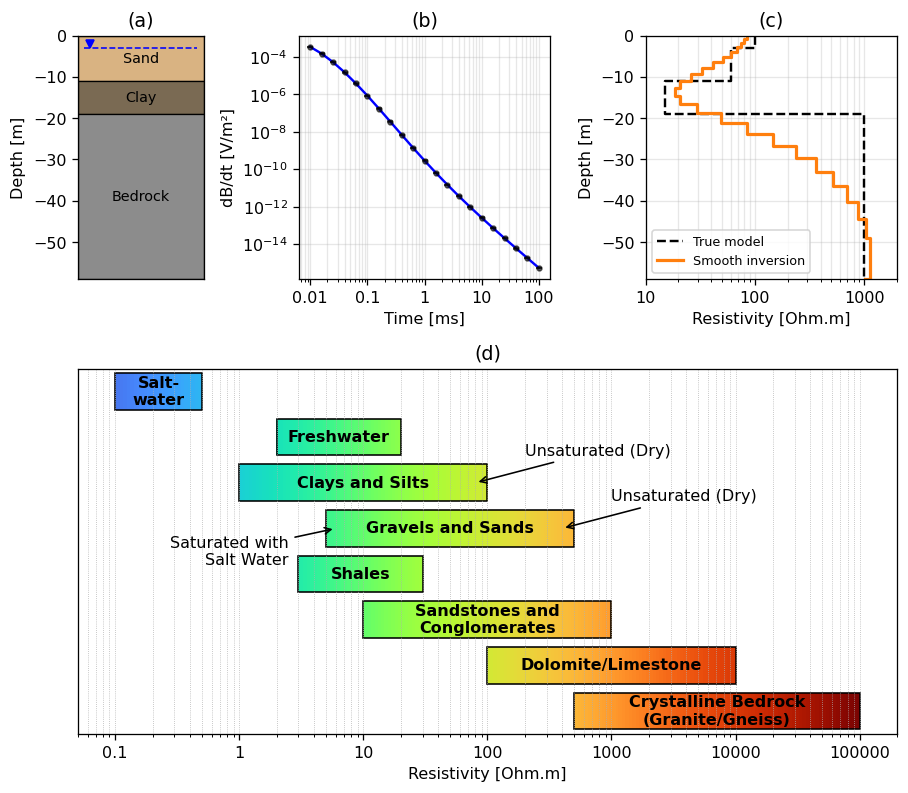

In [4]:
fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(2, 3, width_ratios=[0.5, 1, 1], height_ratios=[1, 1.5])
ax_geo = fig.add_subplot(gs[0, 0])
ax_fwd = fig.add_subplot(gs[0, 1])
ax_mod = fig.add_subplot(gs[0, 2])
ax_rho = fig.add_subplot(gs[1, :])

# Left: geological cross-section built from matplotlib polygons.
layer_colors = ['#d9b382', '#7a6a53', '#8c8c8c']
layer_labels = ['Sand', 'Clay', 'Bedrock']
x_span = (-30.0, 30.0)
# Visual layers merge the dry/saturated sand into a single block; the water
# table itself is drawn separately as a line inside that block.
visual_bottoms = np.array([0.0, schematic_depths[2], schematic_depths[3], schematic_max_depth])
for i in range(3):
    top, bottom = visual_bottoms[i], visual_bottoms[i + 1]
    verts = [(x_span[0], -top), (x_span[1], -top),
             (x_span[1], -bottom), (x_span[0], -bottom)]
    ax_geo.add_patch(Polygon(verts, closed=True, facecolor=layer_colors[i],
                              edgecolor='k', linewidth=0.8))
    ax_geo.text((x_span[0] + x_span[1]) / 2, -(top + bottom) / 2, layer_labels[i],
                ha='center', va='center', fontsize=9)
# Water table: dashed line partway down the sand layer, with the standard
# downward-triangle symbol sitting just above the line.
ax_geo.axhline(-water_table_depth, xmin=0.05, xmax=0.95, color='b', linestyle='--', linewidth=1)
ax_geo.plot(x_span[0] + 6, -water_table_depth + 0.9, marker='v', color='b', ms=5, clip_on=False)
# Tx loop at the surface.
ax_geo.set_xlim(x_span)
ax_geo.set_ylim(-schematic_max_depth, 0)
ax_geo.set_ylabel('Depth [m]')
ax_geo.set_title('(a)')
ax_geo.xaxis.set_visible(False)

# Middle: TEM forward response, with the noisy data used for the inversion.
ax_fwd.loglog(schematic_times*1000, np.abs(schematic_dbdt), 'b-', label='Clean forward')
ax_fwd.errorbar(schematic_times*1000, d_obs, yerr=noise_std, fmt='o', ms=3, capsize=2,
                 color='k', alpha=0.6, label='Noisy data')
ax_fwd.set_xlabel('Time [ms]')
ax_fwd.set_ylabel('dB/dt [V/m²]')
ax_fwd.set_title('(b)')
ax_fwd.grid(True, which='both', alpha=0.3)

# Right: true (sharp) model vs the recovered smooth inversion model.
full_bottoms = np.concatenate([schematic_depths, [schematic_max_depth]])
model_depths = np.repeat(full_bottoms, 2)[1:-1]
model_rhos = np.repeat(schematic_resistivities, 2)
ax_mod.plot(model_rhos, -model_depths, 'k--', lw=1.5, label='True model')
ax_mod.step(np.r_[smooth_rho, smooth_rho[-1]], -np.r_[depths_inv, schematic_max_depth],
            where='pre', color='C1', lw=2, label='Smooth inversion')
ax_mod.set_xscale('log')
ax_mod.set_xlabel('Resistivity [Ohm.m]')
ax_mod.set_ylabel('Depth [m]')
ax_mod.set_title('(c)')
ax_mod.set_ylim(-schematic_max_depth, 0)
ax_mod.set_xlim(10, 2000)
ax_mod.legend(fontsize=8)
ax_mod.grid(True, which='both', alpha=0.3)

# Define materials: name, min_resistivity (Ohm.m), max_resistivity (Ohm.m)
materials = [
    ("Crystalline Bedrock\n(Granite/Gneiss)", 500, 100000),
    ("Dolomite/Limestone", 100, 10000),
    ("Sandstones and\nConglomerates", 10, 1000),
    ("Shales", 3, 30),
    ("Gravels and Sands", 5, 500),
    ("Clays and Silts", 1, 100),
    ("Freshwater", 2, 20),
    ("Salt-\nwater", 0.1, 0.5)
]

# Setup figure

ax_rho.set_xscale('log')
ax_rho.set_xlim(0.05, 200000)
ax_rho.set_ylim(0, len(materials))
ax_rho.set_yticks([])  # Hide y-axis ticks
ax_rho.set_xlabel('Resistivity [Ohm.m]')
ax_rho.set_title('(d)')

# Plot gradient bars
for i, (name, rmin, rmax) in enumerate(materials):
    # Create a gradient along x (log scale)
    x = np.logspace(np.log10(rmin), np.log10(rmax), 500)
    y = np.linspace(i + 0.3, i + 0.7, 2)
    X, Y = np.meshgrid(x, y)

    # Normalize colors by log10
    gradient_values = np.log10(X)
    im = ax_rho.pcolormesh(X, Y, gradient_values, shading='auto', cmap='turbo', alpha=1,
                       vmin=np.log10(0.01), vmax=np.log10(100000))

    rect = patches.Rectangle((rmin, i + 0.1), rmax - rmin, 0.8,
                             linewidth=1, edgecolor='black', facecolor='none')
    ax_rho.add_patch(rect)

    # Add centered label
    ax_rho.text((rmin * rmax)**0.5, i + 0.5, name,
            ha='center', va='center', color='k', fontsize=10, fontweight='bold')

for i, (name, rmin, rmax) in enumerate(materials):
    if name == "Clays and Silts":
        ax_rho.annotate("Unsaturated (Dry)",
                    xy=(rmax*0.8, i + 0.5),
                    xytext=(rmax * 2, i + 1.2),
                    textcoords='data',
                    ha='left', va='center',
                    fontsize=10, color='black',
                    arrowprops=dict(arrowstyle="->", color='black'))

    if name == "Gravels and Sands":
        # Label for saturated
        ax_rho.annotate("Saturated with\nSalt Water",
                    xy=(rmin*1.2, i + 0.5),
                    xytext=(rmin / 2, i),
                    textcoords='data',
                    ha='right', va='center',
                    fontsize=10, color='black',
                    arrowprops=dict(arrowstyle="->", color='black'))

        # Label for unsaturated
        ax_rho.annotate("Unsaturated (Dry)",
                    xy=(rmax*0.8, i + 0.5),
                    xytext=(rmax*2, i + 1.2),
                    textcoords='data',
                    ha='left', va='center',
                    fontsize=10, color='black',
                    arrowprops=dict(arrowstyle="->", color='black'))

# Show logarithmic tick values as complete decimal numbers.
def full_number_formatter(value, position):
    del position
    return f"{value:.10f}".rstrip('0').rstrip('.')

plain_formatter = FuncFormatter(full_number_formatter)
ax_fwd.xaxis.set_major_formatter(plain_formatter)
ax_mod.xaxis.set_major_formatter(plain_formatter)
ax_rho.xaxis.set_major_formatter(plain_formatter)

# Grid
ax_rho.grid(True, which='both', axis='x', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

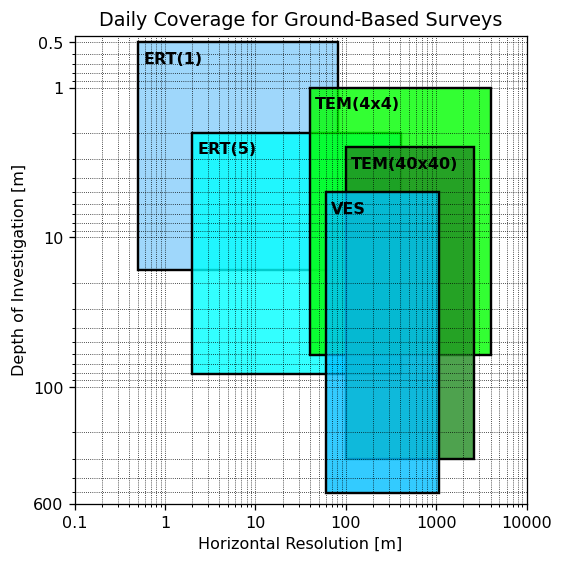

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits and labels
ax.set_xlim(0.1, 10000)
ax.set_ylim(0.45, 600)
ax.invert_yaxis()
ax.set_xlabel('Horizontal Resolution [m]')
ax.set_ylabel('Depth of Investigation [m]')

ax.set_title("Daily Coverage for Ground-Based Surveys")
# Add grid
ax.grid(True, which='both', linestyle=':', linewidth=0.5, c='k')

# Define method areas: (x, y, width, height)
methods = {
    "ERT(1)": (0.5, 0.5, 80.5, 16),
    "ERT(5)": (2, 2, 402, 80),
    "TEM(4x4)": (40, 1, 4000, 60),
    "TEM(40x40)": (100, 2.5, 2500, 300),
    "VES": (60, 5, 1005, 500),  # Added VES
}

colors = {
    "ERT(1)": "lightskyblue",
    "ERT(5)": "cyan",
    "TEM(4x4)": "lime",
    "TEM(40x40)": "forestgreen",
    "VES": "deepskyblue",  # Color for VES
}

# Add rectangles
for method, (x, y, w, h) in methods.items():
    ax.add_patch(patches.Rectangle((x, y), w, h, 
                                   color=colors[method], alpha=0.8, 
                                   label=method, ec='k', lw=1))
    ax.add_patch(patches.Rectangle((x, y), w, h, 
                                   color='none', 
                                   label=method, ec='k', lw=1.5))
    ax.text(x*1.15, y*1.15, method, fontsize=10, color='black', 
             verticalalignment='top', fontweight='bold')


# Add legend (optional)
# ax.legend()
from matplotlib.ticker import FuncFormatter

# Custom tick formatter
def custom_formatter(x, pos):
    if x == 0.1:
        return "0.1"
    else:
        return f"{int(x)}" if x == int(x) else f"{x}"

# Apply to both axes
ax.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))


# Set custom ticks (optional: to control appearance better)
ax.set_xticks([0.1, 1, 10, 100, 1000, 10000])
ax.set_yticks([0.5, 1, 10, 100, 600])

plt.tight_layout()





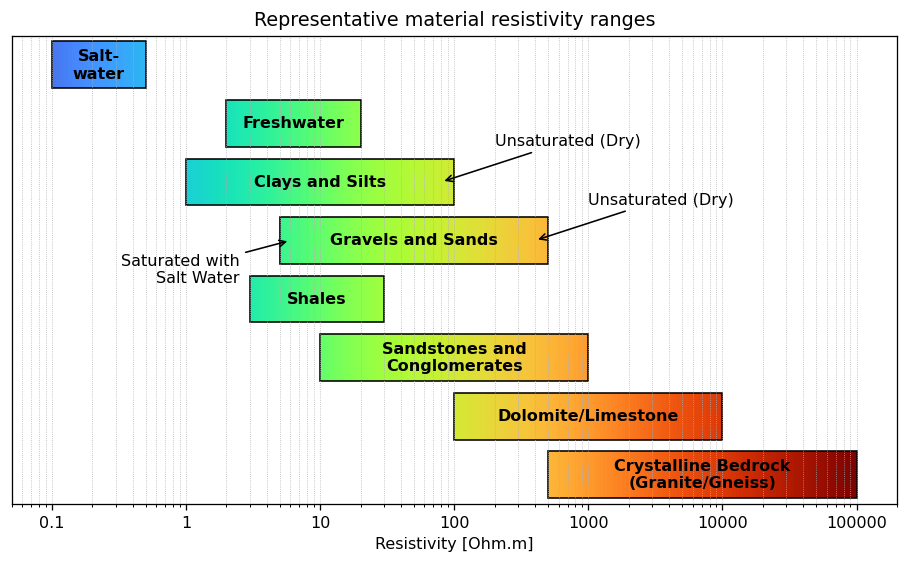

In [6]:
# Standalone version of panel (d): representative material resistivity ranges.
fig_d, ax_rho_d = plt.subplots(figsize=(8, 5))
ax_rho_d.set_xscale('log')
ax_rho_d.set_xlim(0.05, 200000)
ax_rho_d.set_ylim(0, len(materials))
ax_rho_d.set_yticks([])
ax_rho_d.set_xlabel('Resistivity [Ohm.m]')
ax_rho_d.set_title('Representative material resistivity ranges')

for i, (name, rmin, rmax) in enumerate(materials):
    x = np.logspace(np.log10(rmin), np.log10(rmax), 500)
    y = np.linspace(i + 0.3, i + 0.7, 2)
    X, Y = np.meshgrid(x, y)
    gradient_values = np.log10(X)
    ax_rho_d.pcolormesh(
        X, Y, gradient_values, shading='auto', cmap='turbo', alpha=1,
        vmin=np.log10(0.01), vmax=np.log10(100000),
    )
    ax_rho_d.add_patch(patches.Rectangle(
        (rmin, i + 0.1), rmax - rmin, 0.8,
        linewidth=1, edgecolor='black', facecolor='none',
    ))
    ax_rho_d.text(
        (rmin * rmax) ** 0.5, i + 0.5, name,
        ha='center', va='center', color='k', fontsize=10, fontweight='bold',
    )

for i, (name, rmin, rmax) in enumerate(materials):
    if name == "Clays and Silts":
        ax_rho_d.annotate(
            "Unsaturated (Dry)", xy=(rmax * 0.8, i + 0.5),
            xytext=(rmax * 2, i + 1.2), ha='left', va='center', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'),
        )
    if name == "Gravels and Sands":
        ax_rho_d.annotate(
            "Saturated with\nSalt Water", xy=(rmin * 1.2, i + 0.5),
            xytext=(rmin / 2, i), ha='right', va='center', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'),
        )
        ax_rho_d.annotate(
            "Unsaturated (Dry)", xy=(rmax * 0.8, i + 0.5),
            xytext=(rmax * 2, i + 1.2), ha='left', va='center', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'),
        )

def full_number_formatter(value, position):
    del position
    return f"{value:.10f}".rstrip('0').rstrip('.')

ax_rho_d.set_xticks([0.1, 1, 10, 100, 1000, 10000, 100000])
ax_rho_d.xaxis.set_major_formatter(FuncFormatter(full_number_formatter))
ax_rho_d.grid(True, which='both', axis='x', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


The five conceptual models below follow the geometries and groundwater conditions from Fritz's mail. The brackish case uses an electrical conductivity of 2.5 mS/cm, approximately 1500 mg/L TDS, and the saline case represents water above 20 mS/cm. The confined clay is kept at one resistivity above and below the 5 m piezometric level because the saturation effect on clay resistivity is assumed negligible.

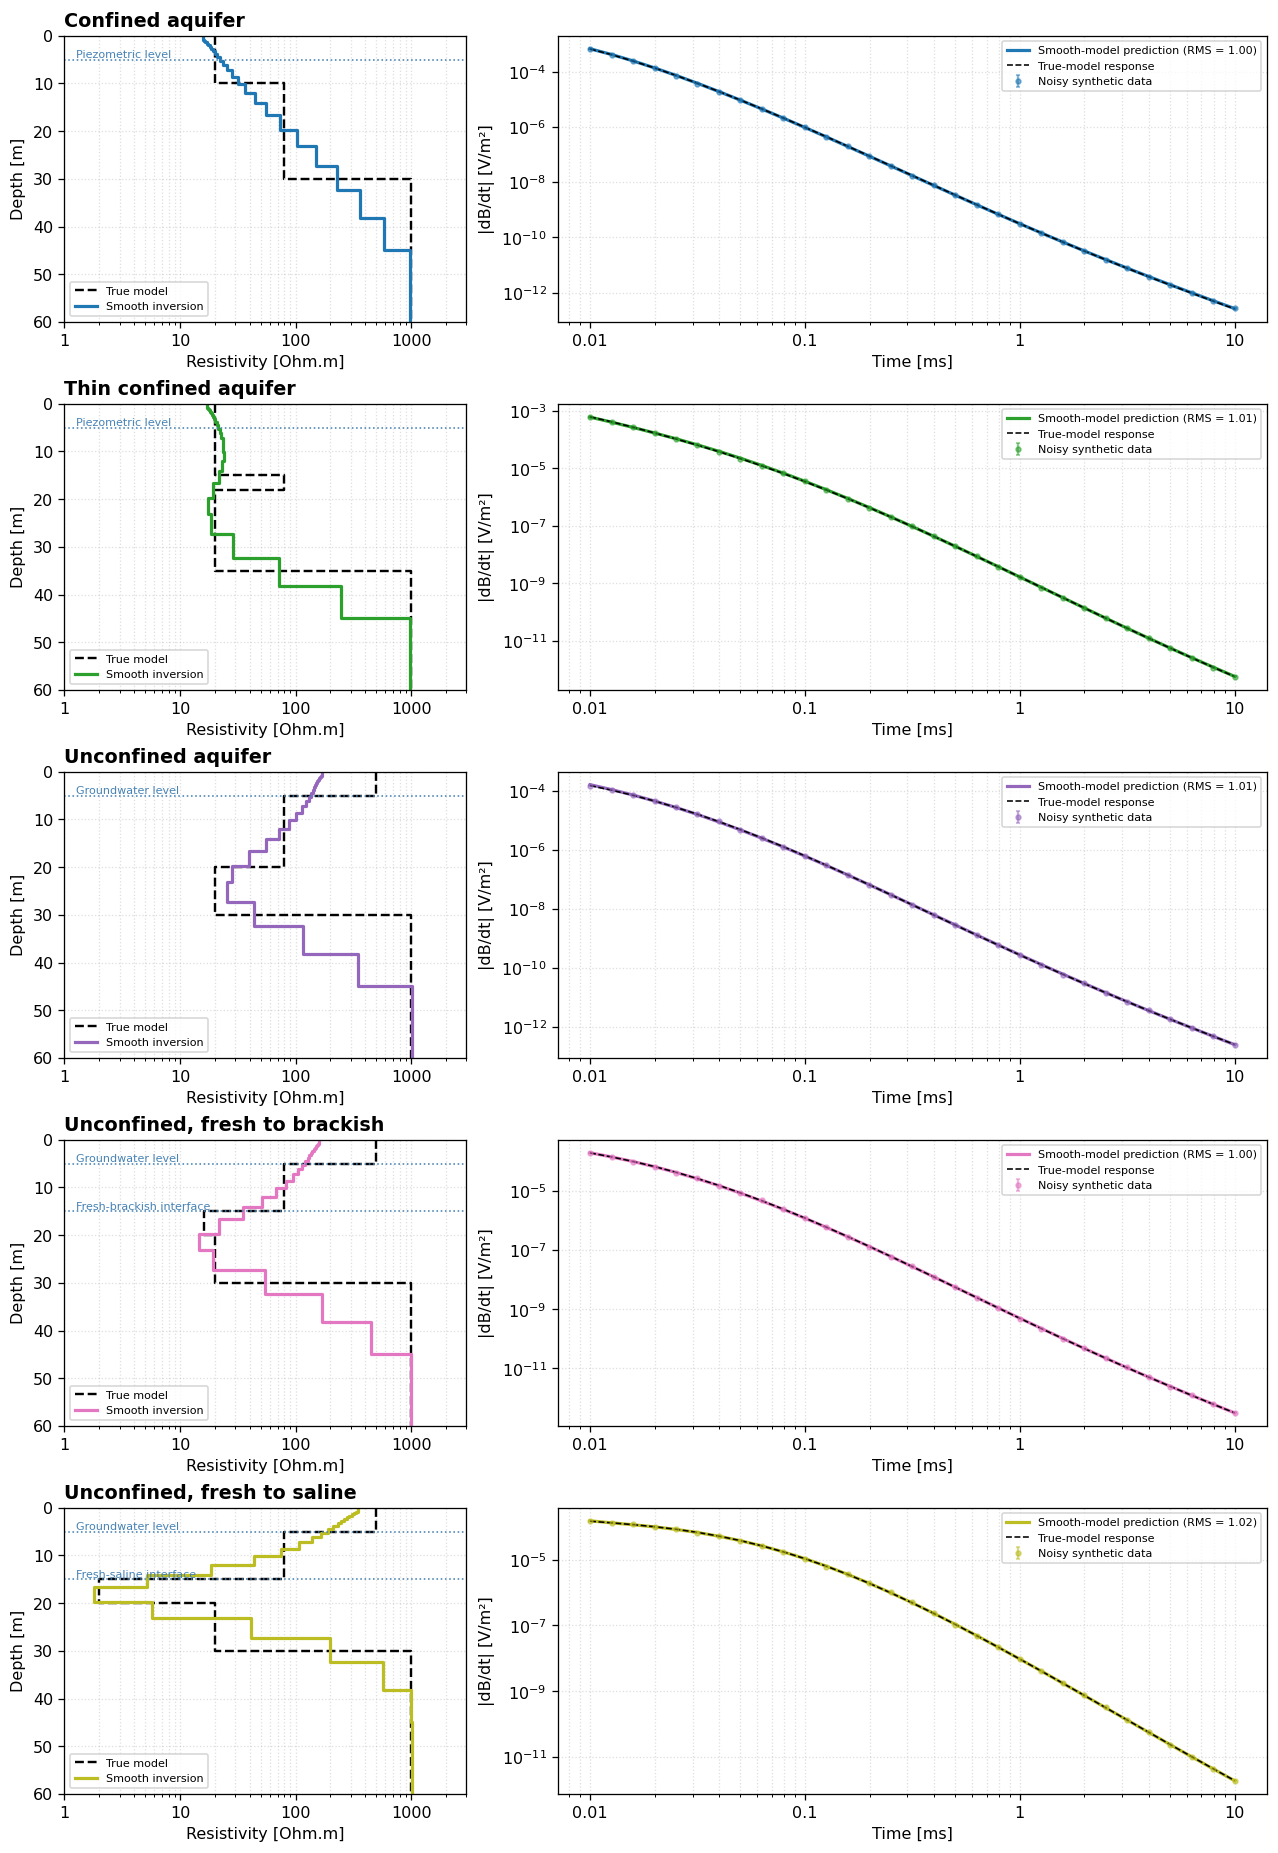

In [7]:
# Forward model and smooth inversion for the five cases proposed by Fritz Kalwa.
cases = {
    "Confined aquifer": {
        "thicknesses": np.array([10.0, 20.0]),
        "resistivities": np.array([20.0, 80.0, 1000.0]),
        "layers": ["Clay", "Fresh sand", "Bedrock"],
        "markers": [(5.0, "Piezometric level")],
    },
    "Thin confined aquifer": {
        "thicknesses": np.array([15.0, 3.0, 17.0]),
        "resistivities": np.array([20.0, 80.0, 20.0, 1000.0]),
        "layers": ["Clay", "Fresh sand", "Clay", "Bedrock"],
        "markers": [(5.0, "Piezometric level")],
    },
    "Unconfined aquifer": {
        "thicknesses": np.array([5.0, 15.0, 10.0]),
        "resistivities": np.array([500.0, 80.0, 20.0, 1000.0]),
        "layers": ["Dry sand", "Fresh sand", "Clay", "Bedrock"],
        "markers": [(5.0, "Groundwater level")],
    },
    "Unconfined, fresh to brackish": {
        "thicknesses": np.array([5.0, 10.0, 5.0, 10.0]),
        "resistivities": np.array([500.0, 80.0, 16.0, 20.0, 1000.0]),
        "layers": ["Dry sand", "Fresh sand", "Brackish sand", "Clay", "Bedrock"],
        "markers": [(5.0, "Groundwater level"), (15.0, "Fresh-brackish interface")],
    },
    "Unconfined, fresh to saline": {
        "thicknesses": np.array([5.0, 10.0, 5.0, 10.0]),
        "resistivities": np.array([500.0, 80.0, 2.0, 20.0, 1000.0]),
        "layers": ["Dry sand", "Fresh sand", "Saline sand", "Clay", "Bedrock"],
        "markers": [(5.0, "Groundwater level"), (15.0, "Fresh-saline interface")],
    },
}

times = np.logspace(-5, -2, 31)
tx_radius = 30.0
plot_bottom = 60.0
noise_fraction = 0.02
colors = plt.cm.tab10(np.linspace(0, 0.8, len(cases)))
rng = np.random.default_rng(42)

# One common 25-layer inversion mesh makes the recovered models comparable.
n_smooth_layers = 25
smooth_bottoms = np.logspace(np.log10(1.0), np.log10(45.0), n_smooth_layers - 1)
smooth_thicknesses = np.diff(np.r_[0.0, smooth_bottoms])
smooth_depth_interfaces = np.r_[0.0, np.cumsum(smooth_thicknesses), plot_bottom]
smooth_start = np.log(np.full(n_smooth_layers, 100.0))

fig, axes = plt.subplots(
    len(cases), 2, figsize=(11, 16),
    gridspec_kw={"width_ratios": [0.85, 1.5]}, constrained_layout=True,
 )
inversions = {}

for row, ((name, case), color) in enumerate(zip(cases.items(), colors)):
    ax_model, ax_response = axes[row]
    thicknesses = case["thicknesses"]
    resistivities = case["resistivities"]
    interfaces = np.concatenate(([0.0], np.cumsum(thicknesses), [plot_bottom]))
    true_depths = np.column_stack((interfaces[:-1], interfaces[1:])).ravel()
    true_rhos = np.repeat(resistivities, 2)

    clean_response = np.abs(fwd_circle_central(
        thicknesses, resistivities, tx_radius, times,
    ))
    noise_std = noise_fraction * clean_response
    observations = np.maximum(
        clean_response + rng.normal(0.0, noise_std),
        np.finfo(float).tiny,
    )

    with contextlib.redirect_stdout(io.StringIO()):
        inversion = invert(
            obs_data=observations,
            thicknesses=smooth_thicknesses,
            log_resistivities=smooth_start.copy(),
            tx_size=tx_radius,
            times=times,
            noise_std=noise_std,
            alpha_steps=8,
            maxit=20,
            max_noise_frac=0.0,
            transform="dlf",
            geometry="circle_central",
            analytical_j=True,
        )

    smooth_rhos = np.asarray(inversion["resistivities"])
    predicted = np.abs(fwd_circle_central(
        smooth_thicknesses, smooth_rhos, tx_radius, times,
    ))
    weighted_rms = np.sqrt(np.mean(((predicted - observations) / noise_std) ** 2))
    inversions[name] = {
        "observations": observations,
        "noise_std": noise_std,
        "predicted": predicted,
        "resistivities": smooth_rhos,
        "weighted_rms": weighted_rms,
    }

    smooth_depths = np.column_stack((
        smooth_depth_interfaces[:-1], smooth_depth_interfaces[1:]
    )).ravel()
    ax_model.semilogx(true_rhos, true_depths, "k--", lw=1.5, label="True model")
    ax_model.semilogx(
        np.repeat(smooth_rhos, 2), smooth_depths, color=color, lw=2,
        label="Smooth inversion",
    )
    for depth, marker_name in case["markers"]:
        ax_model.axhline(depth, color="steelblue", ls=":", lw=1)
        ax_model.text(
            1.1, depth, f"  {marker_name}", color="steelblue",
            va="bottom", fontsize=7,
        )
    ax_model.set_ylim(plot_bottom, 0)
    ax_model.set_xlim(1, 3000)
    ax_model.set_xlabel("Resistivity [Ohm.m]")
    ax_model.set_ylabel("Depth [m]")
    ax_model.set_title(name, loc="left", fontweight="bold")
    ax_model.grid(True, which="both", ls=":", alpha=0.4)
    ax_model.legend(fontsize=7, loc="lower left")

    ax_response.errorbar(
        times * 1000, observations, yerr=noise_std, fmt="o",
        color=color, ecolor=color, ms=3, capsize=1, alpha=0.55,
        label="Noisy synthetic data",
    )
    ax_response.loglog(
        times * 1000, predicted, color=color, lw=2,
        label=f"Smooth-model prediction (RMS = {weighted_rms:.2f})",
    )
    ax_response.loglog(
        times * 1000, clean_response, "k--", lw=1, label="True-model response",
    )
    ax_response.set_xscale("log")
    ax_response.set_yscale("log")
    ax_response.set_xlabel("Time [ms]")
    ax_response.set_ylabel("|dB/dt| [V/m²]")
    ax_response.grid(True, which="both", ls=":", alpha=0.4)
    ax_response.legend(fontsize=7, loc="upper right")

    plain_formatter = FuncFormatter(
        lambda value, position: f"{value:.10f}".rstrip("0").rstrip(".")
    )
    ax_model.xaxis.set_major_formatter(plain_formatter)
    ax_response.xaxis.set_major_formatter(plain_formatter)

plt.show()